# Разработка функционала Алгоритма жадного добавления ADD

https://um.ase.ro/no1S/8.pdf

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx

# Загрузка данных

In [2]:
from fire_units.settings import DEFAULT_SPEEDS
from graphs.speeds import kmh_to_mm, set_graph_travel_times

# G = ox.load_graphml(r'C:\QGIS\Красноярск Демо\______________ef3f7396_30d9_4d94_b617_55ad61b06e30.ml')
G = ox.load_graphml(r'G:\QGIS\_Красноярск ДИССЕРТАЦИЯ\fire_data\rng.ml')
# G = ox.load_graphml(r'D:\QGIS\_Красноярск ДИССЕРТАЦИЯ\fire_data\rng.ml')
print(G.number_of_nodes(), G.number_of_edges())

# Устанавливаем скорости движения
set_graph_travel_times(G, speeds=DEFAULT_SPEEDS, morph_function=kmh_to_mm)

31293 77344


g:\GitRepositories\_Dislocation\genesis\work\genesis\graphs\speeds.py:98: UserWarning: Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. Рекомендуется устанавливать время следования для неупрощенного графа и только после этого упрощать
  warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \


In [3]:
# Загрузка зданий
# buildings = gpd.read_file(r'C:\QGIS\Красноярск Демо\data\bld.gpkg')
buildings = gpd.read_file(r'G:\QGIS\_Красноярск ДИССЕРТАЦИЯ\data\bld.gpkg')
# buildings = gpd.read_file(r'D:\QGIS\_Красноярск ДИССЕРТАЦИЯ\data\bld.gpkg')

# Сопоставляем здания с узлами
# Узлы графа:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf = ox.projection.project_gdf(nodes_gdf)

# Здания
print('Зданий:', len(buildings))
buildings = ox.projection.project_gdf(buildings, to_crs=nodes_gdf.crs)
buildings_centr = buildings.geometry.centroid
nearest_nodes = ox.nearest_nodes(ox.projection.project_graph(G), buildings_centr.x, buildings_centr.y, return_dist=True)
buildings['node'] = nearest_nodes[0]
buildings['node_distance'] = nearest_nodes[1]
buildings = buildings.query('node_distance <= 100')
buildings = ox.projection.project_gdf(buildings, to_latlong=True)
print('Зданий:', len(buildings))

Зданий: 58094
Зданий: 51317


Субсет зданий

In [84]:
df_size = int(len(buildings) * 0.025)
buildings_set = buildings.sample(df_size)
print(f'Расчет для {df_size} зданий')

Расчет для 1282 зданий


# Расчет матрицы времен следования

**ATM** - Arrival Time Matrix

In [ ]:
from genesis.utils import Progressbar, TimeCheckPoint


def get_atm(G,
            data             = None,
            data_sample_size = None,
            data_node_field  = 'node',
            weight           = 'travel_time',
            cutoff           = None,
            ):
    '''
    Расчет матрицы времен следования
    '''

    # Если конкретный набор данных не передан, используем узлы графа
    if data is None:
        data = ox.geocode_to_gdf(G, edges=False)
        data[data_node_field] = data.index

    # Если указана доля набора данных, выбираем его случайным образом из data
    if not data_sample_size is None:
        data = data.sample(data_sample_size)

    # Реверсный граф
    GR = nx.reverse(G, copy=True)

    # перебираем все записи в наборе данных
    d = {}
    pb = Progressbar(len(data), bins=40)
    for id, dt in data.iterrows():
        node = dt[data_node_field]
        length = nx.single_source_dijkstra_path_length(
            GR,
            source = node,
            cutoff = cutoff,
            weight = weight,
            )    
        # d[id] = pd.Series(length)
        d[node] = pd.Series(length)
        pb()

    del GR
    return pd.DataFrame(d).T




print(f'Расчет для {len(buildings_set)} зданий')
t = TimeCheckPoint()

matrix = get_atm(G, data=buildings_set)

print('Размер матрицы:', matrix.shape)
print('Потребовалось времени:', t())

Расчет для 1282 зданий
|########################################| 100.0%
Размер матрицы: (1155, 31074)
Потребовалось времени: 353.02


# Разработка алгоритмов

## Расчет состояния по матрице времени следования (ATM)

In [125]:
from genesis.core import MetricBase, StateBase
from genesis.swiss_knife import DELAY_TIME
from genesis.tools import get_duplicates_list


class CoverMatrixState(StateBase):
    def __init__(self,
                 matrix,
                 state_algorithm = np.min,
                 delay = DELAY_TIME,
                 **kwargs):
        self.matrix = matrix
        self.delay = delay
        super().__init__(state_algorithm, **kwargs)

    def __call__(self,
                 env    = None,
                 points = None,
                 area   = None,
                 **kwargs):
        '''
        `**kwargs`:
            Данные которые используются для расчета.
            
            Согласно правилам genesis, должны быть переданы следующие данные:
            
            `env` (`среда`): None.
                Не используется.

            `points`: list|dict (source)
                Стартовые узлы. Может быть списком узлов вида list(int), или словарем вида dict(int:str), где ключ - 
                идентификатор узла, значение - его наименование. Может использоваться для указания узлов в которых 
                расположены пожарные подразделения: {1234:'ПСЧ-1'}

            `area`: pd.Series = None
                Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
                Если не указана, расчет производится для всех узлов графа.

            Конкретный тип данных и их именование в аргументах осуществляются 
            непосредственно при реализации
        
        # Возвращает
        `state` : abstract
            Состояние среды. Зависит от конкретной реализации
        '''

        if not isinstance(points, (list, dict)):
            raise TypeError('Тип данных аргумента `points` должен быть (list или dict)')
        if isinstance(points, (list)):
            if len(points)!=len(set(points)):
                duplicates = get_duplicates_list(points)
                raise ValueError(f'Значения элементов аргумента `points` не могут повторяться! '
                                 f'Список повторяющихся значений: {duplicates}')

        # Обрезка матрицы по узлам графа
        if not env is None:
            print('Обрезка матрицы по узлам графа')

        if isinstance(points, dict):
            data = self.matrix[points.keys()]
        else:
            data = self.matrix[points]

        times =  self.state_algorithm(data, axis=1)
        times = pd.Series(times, dtype=float, name='times') + self.delay
        
        
        nearest = np.argmin(data, axis=1)
        if isinstance(points, dict):
            units = list(points.values())
        else:
            units = points

        nearest = {k: units[v] for k, v in zip(times.index, nearest)}
        nearest = pd.Series(nearest, dtype=str, name='nearest')

        return times, nearest




state_func = CoverMatrixState(matrix,
                              # state_algorithm=np.min,
                              )  #.copy().notna())


dynamic_nodes = {
    matrix.columns[1000]: 'псч 1',
    matrix.columns[2000]: 'псч 2',
    matrix.columns[3000]: 'псч 3',
    matrix.columns[4000]: 'псч 4',
}
times, nearest = state_func(None, dynamic_nodes)

In [91]:
times

4348216462    11.020825
6953027994     7.957066
1500883969    15.843218
827564361     15.955130
7095340521    13.044757
                ...    
4027261842     3.834674
2305870050    14.129371
357845363      9.247965
2038253633    15.497543
4050100208    16.658816
Name: times, Length: 1155, dtype: float64

In [ ]:
# buildings_set.drop(['times', 'nearest'], axis=1, inplace=True)
buildings_set_2 = pd.merge(
    buildings_set,
    times,
    left_on='node',
    right_index=True
)
buildings_set_2 = pd.merge(
    buildings_set_2,
    nearest,
    left_on='node',
    right_index=True
)
buildings_set_2['geometry'] = buildings_set_2.geometry.centroid

C:\Users\obsid\AppData\Local\Temp\ipykernel_5772\372727460.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings_set_2['geometry'] = buildings_set_2.geometry.centroid


<Axes: >

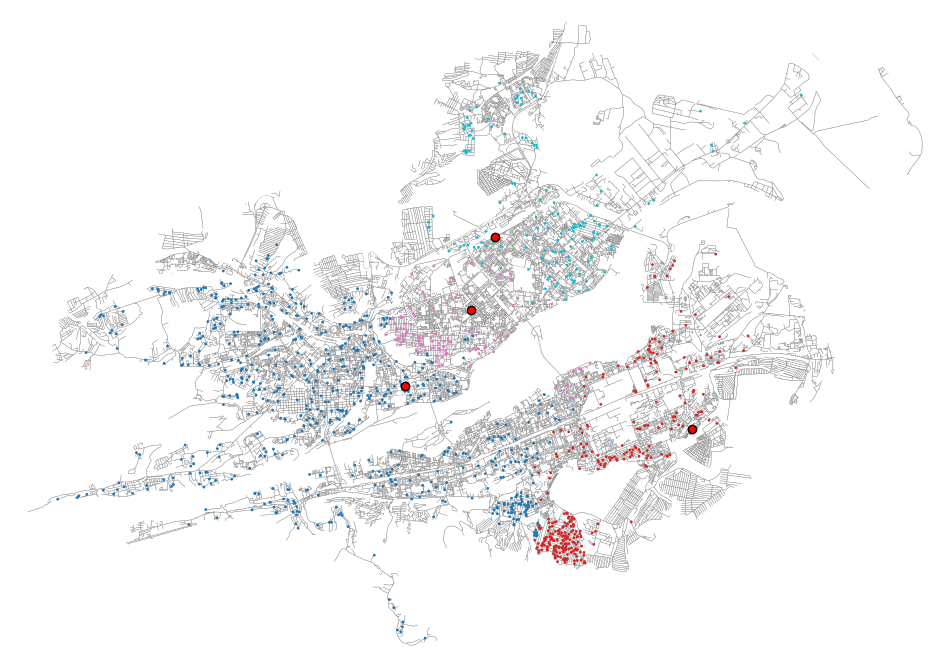

In [104]:
# Карта
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig,ax = ox.plot_graph(
    G,
    figsize=(12,12),
    node_size=0,
    show=False,
    close=False,
    bgcolor='white',
    edge_color='grey',
    edge_linewidth=0.2
    )
nodes_gdf.loc[dynamic_nodes.keys()].plot(
    ax=ax,
    color='red',
    edgecolor='black',
    zorder=1000,
    )
buildings_set_2.plot(
    ax=ax,
    column='nearest',
    markersize=1
    )


## Алгоритм LSCP жадного добавления

In [ ]:
from fire_units.metrics import CoverIndexBuilding

TRAVEL_TIME_MAX = 9

matrix_temp = matrix.copy()  #.notna()
matrix_temp = matrix_temp <= TRAVEL_TIME_MAX
units = []
covered_buildings_count = 0

# common_state
cover_index = CoverIndexBuilding(buildings_set)

print(len(matrix_temp))
while len(matrix_temp) > 0:
    node_id = matrix_temp.columns[np.argmax(np.sum(matrix_temp, axis=0))]
    # node_id = matrix_temp.columns[np.argmax(matrix_temp.sum())]
    units.append(int(node_id))
    node_column = matrix_temp[node_id]

    # Определения количества прикрытых зданий
    covered_buildings_count += node_column.sum()
    print('Прикрыто зданий', node_column.sum(), 'и всего:', covered_buildings_count, 'узел:', node_id)

    matrix_temp = matrix_temp[node_column == False]
    # Расчет ИП-10 Корректный!
    times, _ = state_func(None, units)
    ci10 = cover_index(times)
    print(matrix_temp.shape, f'|| Подразделений = {len(units)} | ИП-10 = {ci10} %', ' '*5)

print('Итого ПСЧ требуется', len(units))

1155
Прикрыто зданий 297 и всего: 297 узел: 345759063
(858, 31074) || Подразделений = 1 | ИП-10 = 24.804992199687987 %      
Прикрыто зданий 257 и всего: 554 узел: 420043086
(601, 31074) || Подразделений = 2 | ИП-10 = 50.0 %      
Прикрыто зданий 114 и всего: 668 узел: 345678885
(487, 31074) || Подразделений = 3 | ИП-10 = 59.12636505460218 %      
Прикрыто зданий 113 и всего: 781 узел: 3774635420
(374, 31074) || Подразделений = 4 | ИП-10 = 68.48673946957878 %      
Прикрыто зданий 90 и всего: 871 узел: 356754232
(284, 31074) || Подразделений = 5 | ИП-10 = 75.66302652106084 %      
Прикрыто зданий 75 и всего: 946 узел: 600113146
(209, 31074) || Подразделений = 6 | ИП-10 = 81.74726989079564 %      
Прикрыто зданий 44 и всего: 990 узел: 415937271
(165, 31074) || Подразделений = 7 | ИП-10 = 85.17940717628706 %      
Прикрыто зданий 39 и всего: 1029 узел: 305580090
(126, 31074) || Подразделений = 8 | ИП-10 = 88.53354134165366 %      
Прикрыто зданий 26 и всего: 1055 узел: 1514360570
(100, 3

In [134]:
buildings_set.columns

Index(['osmid', 'name', 'amenity', 'building', 'addr:street',
       'addr:housenumber', 'building:levels', 'building:flats', 'rooms',
       'kfpo', 'kfpo_value', 'kfpo_fires_density', 'p_1140', 'p_1140_d',
       'kfpo_spros', 'geometry', 'node', 'node_distance'],
      dtype='object')

C:\Users\obsid\AppData\Local\Temp\ipykernel_5772\1732861131.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings_set_2['geometry'] = buildings_set_2.geometry.centroid


<Axes: >

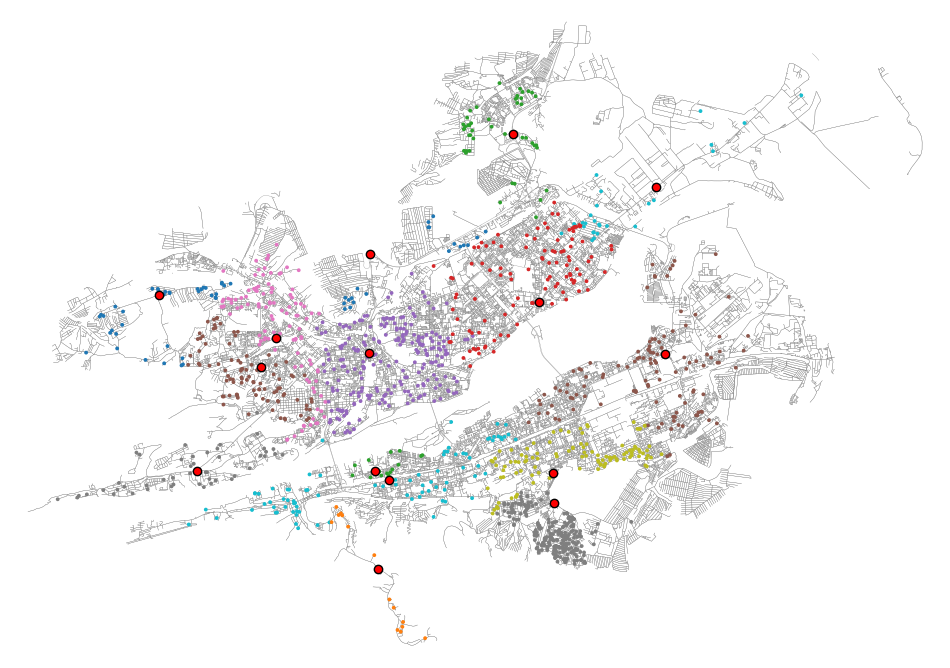

In [137]:
current_nodes = units[:15]
times, nearest = state_func(None, current_nodes)

# buildings_set.drop(['times', 'nearest'], axis=1, inplace=True)
buildings_set_2 = pd.merge(
    buildings_set,
    times,
    left_on='node',
    right_index=True
)
buildings_set_2 = pd.merge(
    buildings_set_2,
    nearest,
    left_on='node',
    right_index=True
)
buildings_set_2['geometry'] = buildings_set_2.geometry.centroid

# Карта
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig,ax = ox.plot_graph(
    G,
    figsize=(12,12),
    node_size=0,
    show=False,
    close=False,
    bgcolor='white',
    edge_color='grey',
    edge_linewidth=0.2
    )
nodes_gdf.loc[current_nodes].plot(
    ax=ax,
    color='red',
    edgecolor='black',
    zorder=1000,
    )
buildings_set_2.plot(
    ax=ax,
    column='nearest',
    markersize=3
    )